In [ ]:
# Install runtime dependencies used by this notebook
%pip install --quiet opencv-python Pillow matplotlib

<h2 style='color:blue' align='center'>Data Augmentation To Address Overfitting In Flower Classification CNN</h2>

**In this notebook we will build a CNN to classify flower images. We will also see how our model overfits and how overfitting can be addressed using data augmentation. Data augmentation is a process of generating new training samples from current training dataset using transformations such as zoom, rotations, change in contrast etc**

Credits: I used tensorflow offical tutorial: https://www.tensorflow.org/tutorials/images/classification as a reference and made bunch of changes to make it simpler

In below image, 4 new training samples are generated from original sample using different transformations

<img src="daisy2.JPG" />

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

We will download flowers dataset from google website and store it locally. In below call it downloads the zip file (.tgz) in cache_dir which is . meaning the current folder

<h3 style='color:purple'>Load flowers dataset</h3>

In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [4]:
data_dir

'./datasets/flower_photos'

In [5]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [6]:
list(data_dir.glob('*/*.jpg'))[:5]

[]

In [7]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

0


In [8]:
import pathlib

data_dir = pathlib.Path("./datasets/flower_photos/flower_photos")

roses = list(data_dir.glob('roses/*.jpg'))

print("Number of rose images:", len(roses))
print(roses[:5])

Number of rose images: 641
[PosixPath('datasets/flower_photos/flower_photos/roses/388405293_4db1d71f21_n.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/3494252600_29f26e3ff0_n.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/2197754124_5c8a146761_n.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/15333843782_060cef3030.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/16229215579_e7dd808e9c.jpg')]


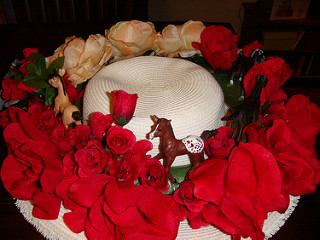

In [9]:
PIL.Image.open(str(roses[1]))

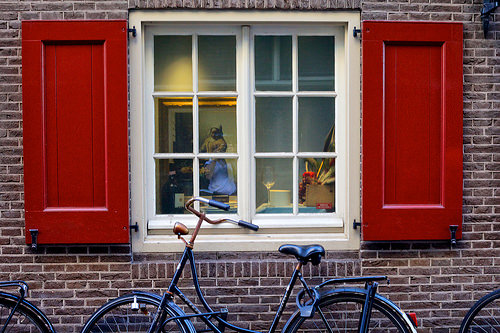

In [10]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

<h3 style='color:purple'>Read flowers images from disk into numpy array using opencv</h3>

In [11]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [12]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [13]:
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/388405293_4db1d71f21_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3494252600_29f26e3ff0_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2197754124_5c8a146761_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15333843782_060cef3030.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16229215579_e7dd808e9c.jpg')]

In [14]:
str(flowers_images_dict['roses'][0])

'datasets/flower_photos/flower_photos/roses/388405293_4db1d71f21_n.jpg'

In [15]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [16]:
img.shape

(240, 320, 3)

In [17]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [18]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [19]:
X = np.array(X)
y = np.array(y)

<h3 style='color:purple'>Train test split</h3>

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

<h3 style='color:purple'>Preprocessing: scale images</h3>

In [21]:
# X_train_scaled = X_train / 255
# X_test_scaled = X_test / 255

<h3 style='color:purple'>Build convolutional neural network and train it</h3>

In [23]:
num_classes = 5

model = Sequential([

    layers.Rescaling(1./255, input_shape=(180,180,3)),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=4
)

Epoch 1/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.4611 - loss: 1.2709
Epoch 2/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.6054 - loss: 1.0128
Epoch 3/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.6933 - loss: 0.8081
Epoch 4/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.8009 - loss: 0.5179
Epoch 5/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.8986 - loss: 0.2919
Epoch 6/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 76s 111ms/step - accuracy: 0.9477 - loss: 0.1589
Epoch 7/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 77s 112ms/step - accuracy: 0.9764 - loss: 0.0751
Epoch 8/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 76s 110ms/step - accuracy: 0.9811 - loss: 0.0640
Epoch 9/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 76s 111ms/step - accuracy: 0.9869 - loss: 0.0555
Epoch 10/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 76s 110ms/step - accuracy: 0.9815 - loss: 0.0727
Epoch 11/30
688/688 ━━━━━━━━━━━━━━━━━━━━ 77s 111ms/step - accuracy: 0.9720 - loss: 0.0983
Epoch 12/30
688/688 ━━━━

In [25]:
model.evaluate(X_test,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6362 - loss: 3.8938


[3.893779754638672, 0.6361655592918396]

**Here we see that while train accuracy is very high (99%), the test accuracy is significantly low (66.99%) indicating overfitting. Let's make some predictions before we use data augmentation to address overfitting**

In [26]:
predictions = model.predict(X_test)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step


array([[-21.624105  ,   5.478795  ,  12.57565   ,   1.2550427 ,
         -3.6460238 ],
       [  1.1667081 ,  -6.8345156 ,  -9.74525   ,   0.984957  ,
         10.82612   ],
       [ -2.8895867 ,  -0.3147685 ,  10.174537  , -14.395801  ,
         -7.500222  ],
       ...,
       [-14.505326  ,   7.6788297 ,   0.80032486,   3.3431296 ,
         -2.2443843 ],
       [ 19.413538  ,  -4.6617856 ,  -4.7475843 , -16.428423  ,
          1.2833296 ],
       [  0.8933964 ,  -0.56740314, -12.813534  ,   9.036262  ,
          4.968188  ]], shape=(918, 5), dtype=float32)

In [27]:
score = tf.nn.softmax(predictions[0])

In [28]:
np.argmax(score)

np.int64(2)

In [29]:
y_test[0]

np.int64(1)

<h3 style='color:purple'>Improve Test Accuracy Using Data Augmentation</h3>

In [32]:
img_height = 180
img_width = 180

In [33]:
data_augmentation = keras.Sequential([
    
    layers.RandomFlip(
        "horizontal",
        input_shape=(img_height, img_width, 3)
    ),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

])

**Original Image**

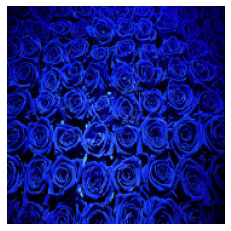

In [34]:
plt.axis('off')
plt.imshow(X[0])

**Newly generated training sample using data augmentation**

In [ ]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

<h3 style='color:purple'>Train the model using data augmentation and a drop out layer</h3>

In [ ]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train, y_train, epochs=30)    

Epoch 1/30
86/86 [==============================] - 1s 17ms/step - loss: 1.4347 - accuracy: 0.3844
Epoch 2/30
86/86 [==============================] - 1s 16ms/step - loss: 1.0742 - accuracy: 0.5789
Epoch 3/30
86/86 [==============================] - 1s 15ms/step - loss: 0.9900 - accuracy: 0.6130
Epoch 4/30
86/86 [==============================] - 1s 13ms/step - loss: 0.9247 - accuracy: 0.6421
Epoch 5/30
86/86 [==============================] - 1s 14ms/step - loss: 0.8485 - accuracy: 0.6722
Epoch 6/30
86/86 [==============================] - 1s 16ms/step - loss: 0.8226 - accuracy: 0.6893
Epoch 7/30
86/86 [==============================] - 1s 14ms/step - loss: 0.7964 - accuracy: 0.6944
Epoch 8/30
86/86 [==============================] - 1s 15ms/step - loss: 0.7662 - accuracy: 0.7140
Epoch 9/30
86/86 [==============================] - 1s 16ms/step - loss: 0.7292 - accuracy: 0.7249
Epoch 10/30
86/86 [==============================] - 2s 18ms/step - loss: 0.6941 - accuracy: 0.7362
Epoch 11/

In [ ]:
model.evaluate(X_test,y_test)

29/29 [==============================] - 0s 5ms/step - loss: 0.8419 - accuracy: 0.7375


[0.8418797850608826, 0.7374727725982666]

**You can see that by using data augmentation and drop out layer the accuracy of test set predictions is increased to 73.74%**